# Task 1: Iris Dataset
**DevelopersHub Corporation | Data Science & Analytics Internship**
#
# **By: Muhammad Yahya Imran**


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset

In [2]:
# Fetch Iris dataset via seaborn's built-in loader
df = sns.load_dataset('iris')
print('Dataset Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Dataset Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 3: Dataset Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Inspect for any missing entries
print('Missing values:')
print(df.isnull().sum())

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [5]:
# Statistical overview of features
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Tally of samples per species
print('Species distribution:')
print(df['species'].value_counts())

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

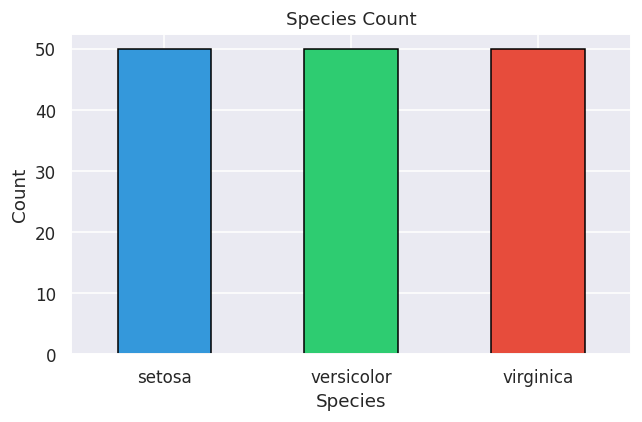

In [7]:
# Tally of samples per species bar plot
plt.figure(figsize=(6, 4))
df['species'].value_counts().plot(kind='bar', color=['#3498DB', '#2ECC71', '#E74C3C'], edgecolor='black')
plt.title('Species Count')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

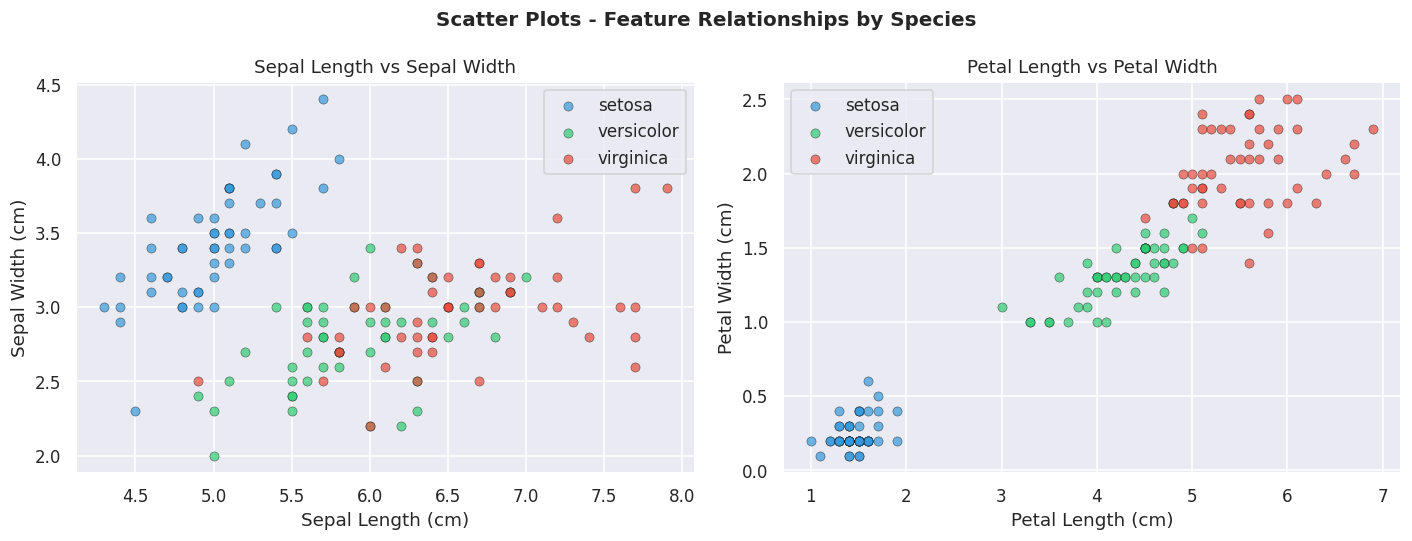

In [8]:
# Scatter plots to explore inter-feature relationships
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sepal length vs Sepal width
species_colors = {'setosa': '#3498DB', 'versicolor': '#2ECC71', 'virginica': '#E74C3C'}
for species, group in df.groupby('species'):
    axes[0].scatter(group['sepal_length'], group['sepal_width'],
                    label=species, color=species_colors[species], alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_title('Sepal Length vs Sepal Width')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].legend()

# Petal length vs Petal width
for species, group in df.groupby('species'):
    axes[1].scatter(group['petal_length'], group['petal_width'],
                    label=species, color=species_colors[species], alpha=0.7, edgecolors='black', linewidth=0.3)
axes[1].set_title('Petal Length vs Petal Width')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle('Scatter Plots - Feature Relationships by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

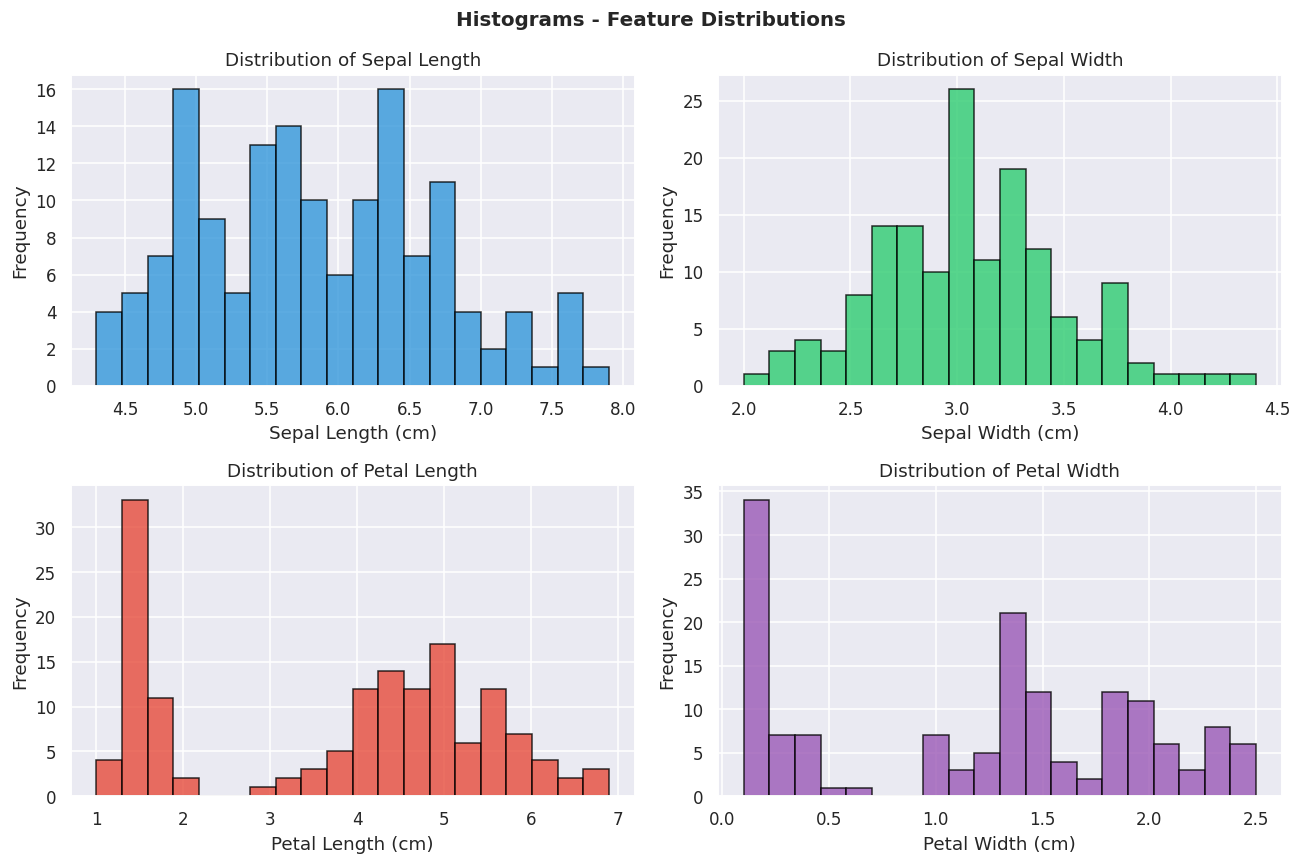

In [9]:
# Histogram grid to visualize feature distributions
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors   = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (feature, color) in enumerate(zip(features, colors)):
    axes[i].hist(df[feature], bins=20, color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace('_', ' ').title() + ' (cm)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms - Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

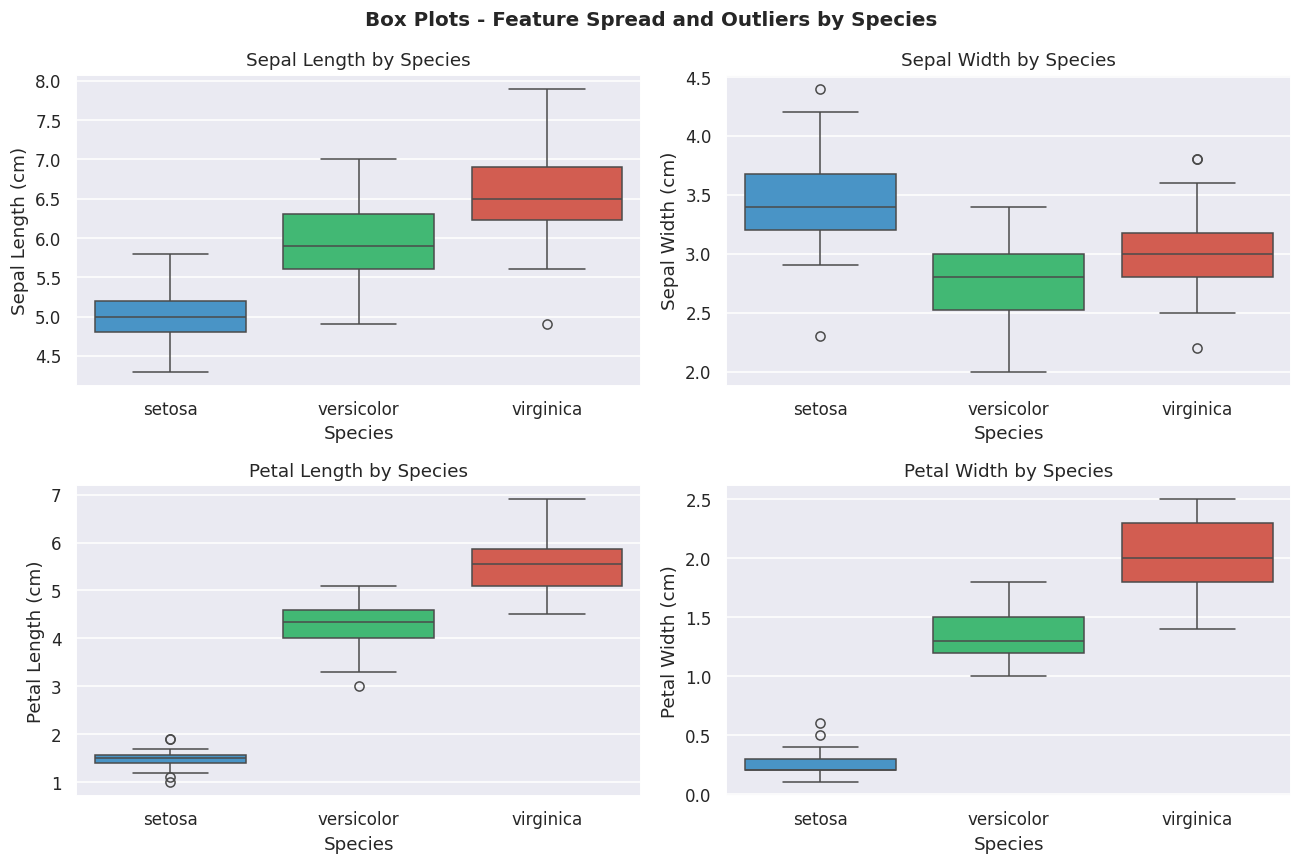

In [10]:
# Box plots for spread and outlier comparison across species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i],
                palette={'setosa': '#3498DB', 'versicolor': '#2ECC71', 'virginica': '#E74C3C'})
    axes[i].set_title(f'{feature.replace("_", " ").title()} by Species')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feature.replace('_', ' ').title() + ' (cm)')

plt.suptitle('Box Plots - Feature Spread and Outliers by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

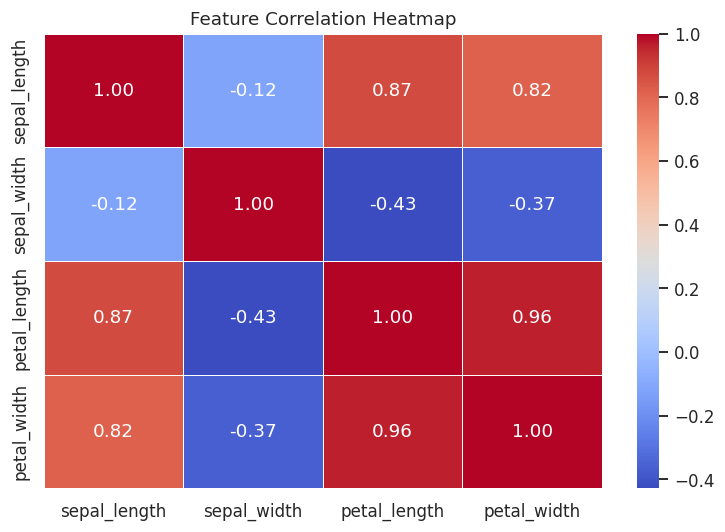

In [11]:
# Heatmap of pairwise feature correlations
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

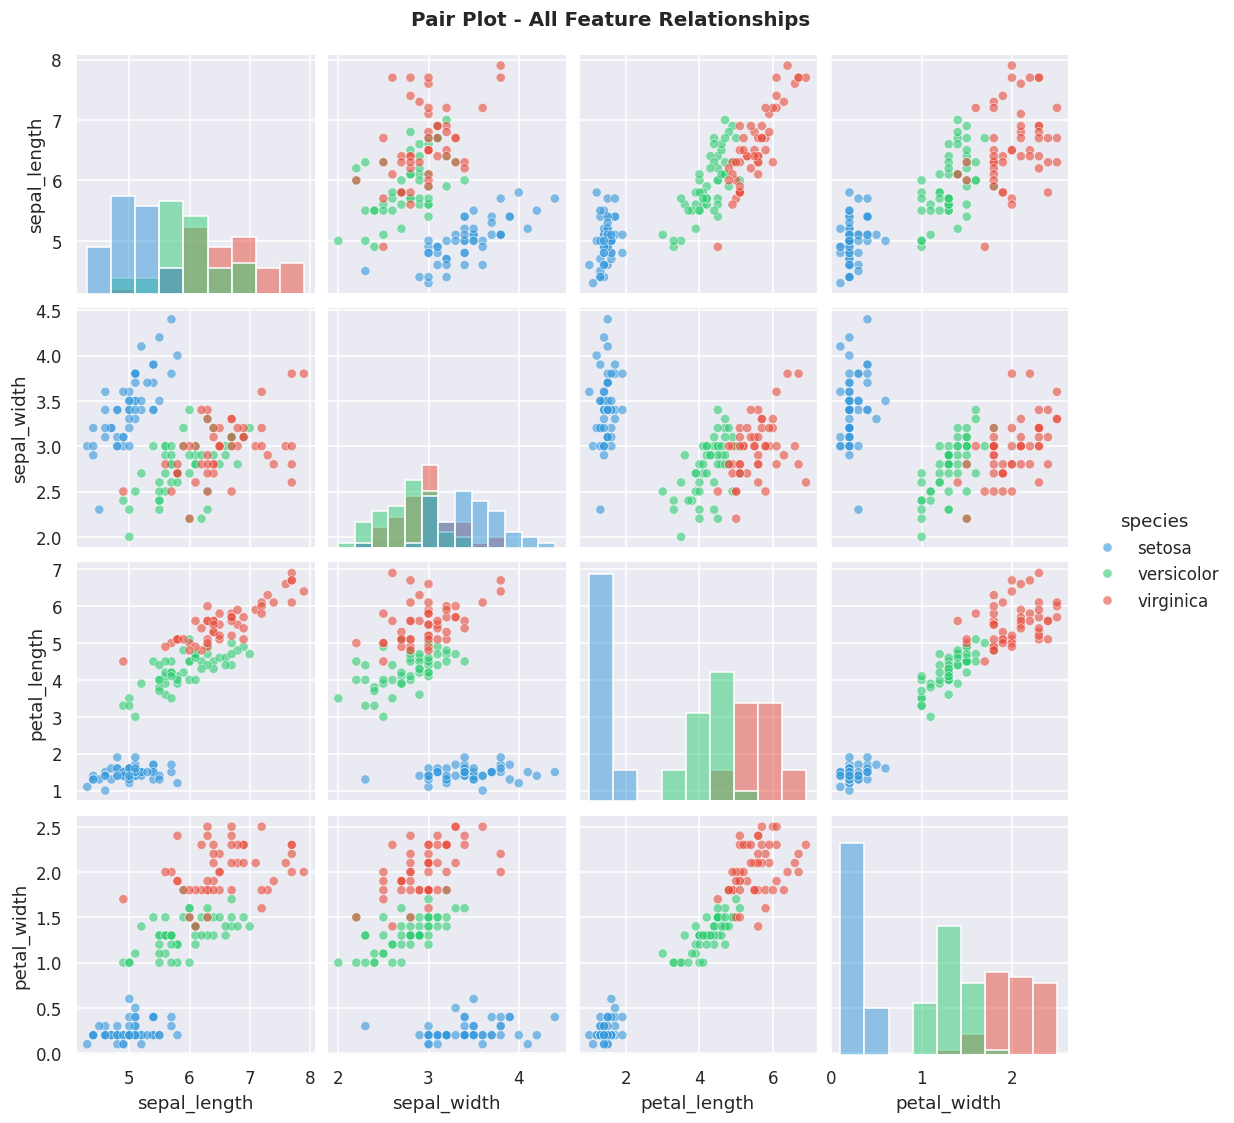

In [12]:
# Pair plot for a full cross-feature view
sns.pairplot(df, hue='species',
             palette={'setosa': '#3498DB', 'versicolor': '#2ECC71', 'virginica': '#E74C3C'},
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - All Feature Relationships', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [14]:
print('Dataset Summary:')
print(f'  Total samples    : {len(df)}')
print(f'  Features         : {features}')
print(f'  Species          : {df["species"].unique().tolist()}')
print(f'  Samples per class: {df["species"].value_counts().to_dict()}')

print('\nKey Findings:')
print('  - The dataset has 150 samples equally distributed across 3 species (50 each).')
print('  - Petal length and petal width are highly correlated (r = 0.96).')
print('  - Setosa is clearly separable from the other two species based on petal size.')
print('  - Versicolor and Virginica overlap slightly, making them harder to distinguish.')
print('  - No missing values were found in the dataset.')
print('  - Box plots show that petal features have more variation across species than sepal features.')

Dataset Summary:
  Total samples    : 150
  Features         : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
  Species          : ['setosa', 'versicolor', 'virginica']
  Samples per class: {'setosa': 50, 'versicolor': 50, 'virginica': 50}

Key Findings:
  - The dataset has 150 samples equally distributed across 3 species (50 each).
  - Petal length and petal width are highly correlated (r = 0.96).
  - Setosa is clearly separable from the other two species based on petal size.
  - Versicolor and Virginica overlap slightly, making them harder to distinguish.
  - No missing values were found in the dataset.
  - Box plots show that petal features have more variation across species than sepal features.


## Step 5: Model Training & Evaluation
Even though this task focuses on EDA, a simple classification model is trained to evaluate how well the features separate the three species.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Convert species labels to numeric form
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
y = df['species_encoded']

# Partition data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalise features using standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print('Model: Random Forest Classifier')
print('Accuracy:', round(acc, 4))

Model: Random Forest Classifier
Accuracy: 0.9


In [16]:
# Detailed per-class performance report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



<Figure size 660x440 with 0 Axes>

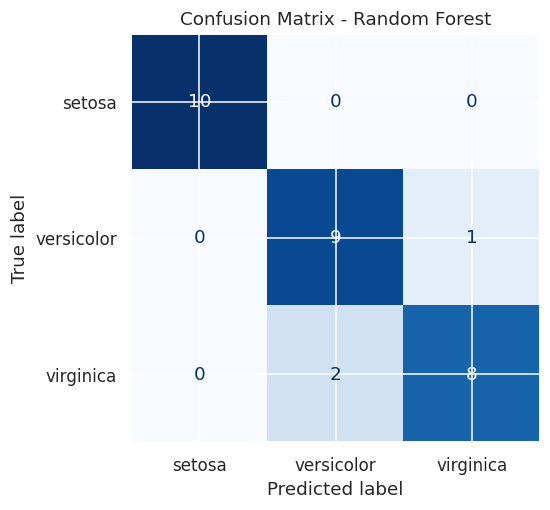

In [17]:
# Visualize prediction results with a confusion matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=le.classes_).plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

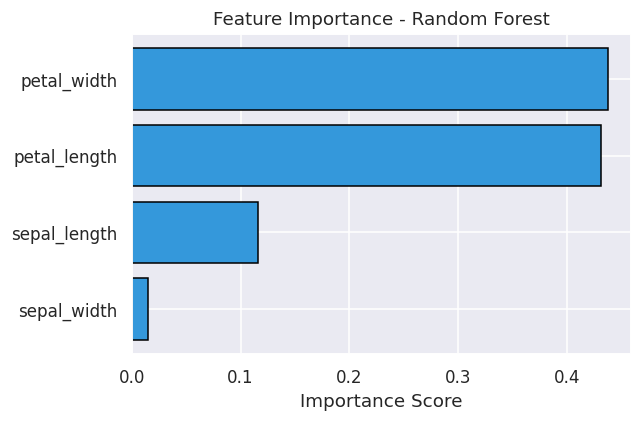

In [18]:
# Bar chart of feature contribution scores
feat_imp = pd.DataFrame({
    'Feature'   : features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(6, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498DB', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 6: Conclusion

In [19]:
print('Dataset Summary:')
print(f'  Total samples    : {len(df)}')
print(f'  Features         : {features}')
print(f'  Species          : {df["species"].unique().tolist()}')
print(f'  Samples per class: {df["species"].value_counts().to_dict()}')
print(f'\nModel Accuracy    : {acc:.2%}')
print('\nKey Findings:')
print('  - Dataset is balanced with 50 samples per species and no missing values.')
print('  - Petal length and petal width are the most important features for classification.')
print('  - Setosa is easily separable from the other species based on petal dimensions.')
print('  - Versicolor and Virginica have some overlap but are still distinguishable.')
print('  - Random Forest achieved high accuracy on this well-structured dataset.')

Dataset Summary:
  Total samples    : 150
  Features         : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
  Species          : ['setosa', 'versicolor', 'virginica']
  Samples per class: {'setosa': 50, 'versicolor': 50, 'virginica': 50}

Model Accuracy    : 90.00%

Key Findings:
  - Dataset is balanced with 50 samples per species and no missing values.
  - Petal length and petal width are the most important features for classification.
  - Setosa is easily separable from the other species based on petal dimensions.
  - Versicolor and Virginica have some overlap but are still distinguishable.
  - Random Forest achieved high accuracy on this well-structured dataset.
